# 04 - Model Evaluation

In [2]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import joblib, os

df = pd.read_csv('/Users/yousseftamerfaisal/Desktop/full_churn_portfolio_project/churn.csv')
df = pd.get_dummies(df, drop_first=True)

target = [c for c in df.columns if 'churn' in c.lower()][0]

X = df.drop(target, axis=1)
y = df[target]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier(n_estimators=300)
model.fit(X_train,y_train)

pred = model.predict(X_test)


In [3]:

cm = confusion_matrix(y_test,pred)
print("Confusion Matrix")
print(cm)


Confusion Matrix
[[11469  1825]
 [ 3267  3439]]


ROC AUC: 0.7974282633620059


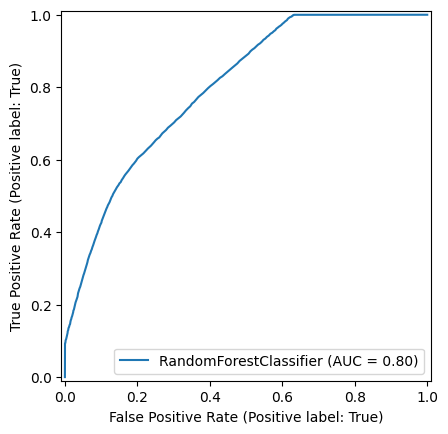

In [4]:

roc = roc_auc_score(y_test,model.predict_proba(X_test)[:,1])
print("ROC AUC:",roc)

RocCurveDisplay.from_estimator(model,X_test,y_test)
plt.show()


In [5]:

importance = model.feature_importances_

import pandas as pd
imp_df = pd.DataFrame({
"Feature":X.columns,
"Importance":importance
}).sort_values(by="Importance",ascending=False)

imp_df.head(10)


,Feature,Importance
3,MonthlyCharges,0.239823
2,Tenure,0.173607
4,TotalCharges,0.173168
0,CustomerID,0.155052
1,Age,0.119995
7,Contract_One year,0.050814
8,Contract_Two year,0.047039
5,Gender_Male,0.010909
10,PaymentMethod_Electronic check,0.009291
11,PaymentMethod_Mailed check,0.008117


In [6]:

os.makedirs('../models',exist_ok=True)
joblib.dump(model,'../models/churn_model.pkl')


['../models/churn_model.pkl']